In [1]:
# Cài thư viện còn thiếu
!pip install nlpaug

# Hạ cấp protobuf để sửa lỗi 'MessageFactory' (xung đột version giữa tensorflow/tensorboard và protobuf)
!pip install protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
ray 2.52.1 requires click!=8.3.*,>=7.0, but you have click 8.3.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2

In [2]:
# Import required libraries
import numpy as np

import pandas as pd, numpy as np, random, re, gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_auc_score, precision_score, recall_score, roc_curve
import tensorflow as tf
from keras.utils import to_categorical
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import warnings
from collections import Counter
# ===============================
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import nlpaug.augmenter.word as naw
from transformers import MarianMTModel, MarianTokenizer
import pandas as pd
import torch
from transformers import MarianMTModel, MarianTokenizer

SEED = 42
warnings.filterwarnings('ignore')
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
print("Libraries imported successfully!")

2025-12-26 19:02:56.382383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766775776.557071      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766775776.612172      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766775777.047536      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766775777.047577      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766775777.047586      23 computation_placer.cc:177] computation placer alr

Libraries imported successfully!


In [3]:
# Download required NLTK data
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download('extended_omw')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package extended_omw to
[nltk_data]     /usr/share/nltk_data...
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
import os
import pandas as pd
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
pretty_counts = pd.Series(
    {
        "positive": 40106,
        "negative": 30663,
        "neutral": 11501,
    },
    name="count"
)

In [5]:
MODEL_NAME = 'bert-base-multilingual-cased'
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 2e-5

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
df = pd.read_csv(r"/kaggle/input/new-data/New_data/csv/train/train_final.csv")

In [7]:
print(df.shape)

(29937, 7)


In [8]:
df.head()

,review_id,sentence_id,sentence,target,category,polarity,language
0,g1079435-d3498474-r271346275,g1079435-d3498474-r271346275:0,"Un service passable .. Des plats surcuits, des...",service,SERVICE#GENERAL,neutral,french
1,g1079435-d3498474-r271346275,g1079435-d3498474-r271346275:0,"Un service passable .. Des plats surcuits, des...",plats,FOOD_DRINKS#QUALITY,negative,french
2,g1079435-d3498474-r271346275,g1079435-d3498474-r271346275:0,"Un service passable .. Des plats surcuits, des...",sauces,FOOD_DRINKS#QUALITY,negative,french
3,g1079435-d3498474-r271346275,g1079435-d3498474-r271346275:0,"Un service passable .. Des plats surcuits, des...",NaN,RESTAURANT#PRICE,neutral,french
4,g1079435-d3498474-r271346275,g1079435-d3498474-r271346275:0,"Un service passable .. Des plats surcuits, des...",NaN,FOOD_DRINKS#QUALITY,negative,french


In [9]:
def check_df(df: object, head: object = 5) -> object:
    print("\nShape")
    print(df.shape)
    print("\nTypes")
    print(df.dtypes)
    print("\nNANs")
    print(df.isnull().sum())
    print("\nInfo")
    print(df.info())
check_df(df)


Shape
(29937, 7)

Types
review_id      object
sentence_id    object
sentence       object
target         object
category       object
polarity       object
language       object
dtype: object

NANs
review_id         0
sentence_id       0
sentence          0
target         8948
category          0
polarity          0
language          0
dtype: int64

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29937 entries, 0 to 29936
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    29937 non-null  object
 1   sentence_id  29937 non-null  object
 2   sentence     29937 non-null  object
 3   target       20989 non-null  object
 4   category     29937 non-null  object
 5   polarity     29937 non-null  object
 6   language     29937 non-null  object
dtypes: object(7)
memory usage: 1.6+ MB
None


In [10]:
print('Number of duplicated rows: ' , len(df[df.duplicated()]))

Number of duplicated rows:  307


In [11]:
df.head()

,review_id,sentence_id,sentence,target,category,polarity,language
0,g1079435-d3498474-r271346275,g1079435-d3498474-r271346275:0,"Un service passable .. Des plats surcuits, des...",service,SERVICE#GENERAL,neutral,french
1,g1079435-d3498474-r271346275,g1079435-d3498474-r271346275:0,"Un service passable .. Des plats surcuits, des...",plats,FOOD_DRINKS#QUALITY,negative,french
2,g1079435-d3498474-r271346275,g1079435-d3498474-r271346275:0,"Un service passable .. Des plats surcuits, des...",sauces,FOOD_DRINKS#QUALITY,negative,french
3,g1079435-d3498474-r271346275,g1079435-d3498474-r271346275:0,"Un service passable .. Des plats surcuits, des...",NaN,RESTAURANT#PRICE,neutral,french
4,g1079435-d3498474-r271346275,g1079435-d3498474-r271346275:0,"Un service passable .. Des plats surcuits, des...",NaN,FOOD_DRINKS#QUALITY,negative,french


In [12]:
print("Class distribution:")
print(df['polarity'].value_counts())

Class distribution:
polarity
positive    18653
negative     9401
neutral      1883
Name: count, dtype: int64


<Axes: xlabel='polarity', ylabel='count'>

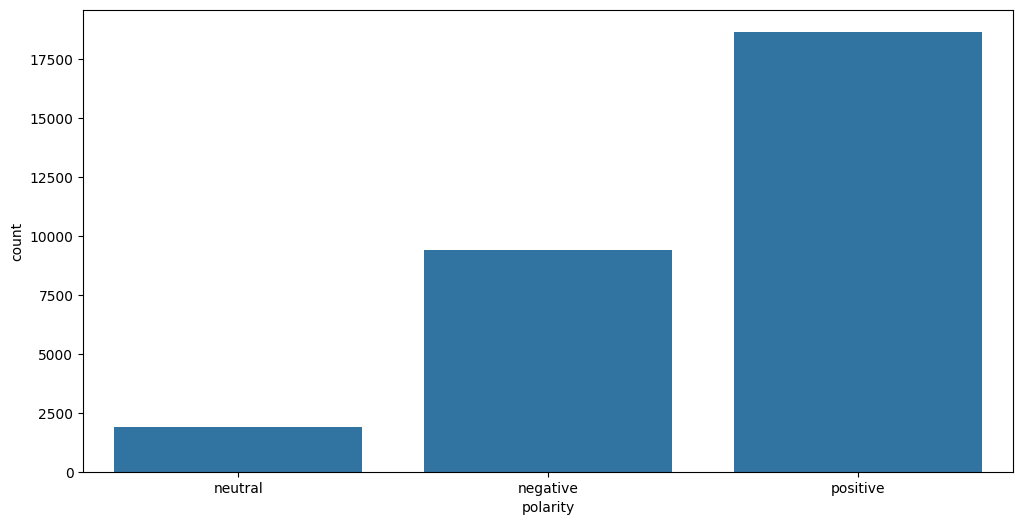

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(x='polarity',data=df)

<Axes: xlabel='language', ylabel='count'>

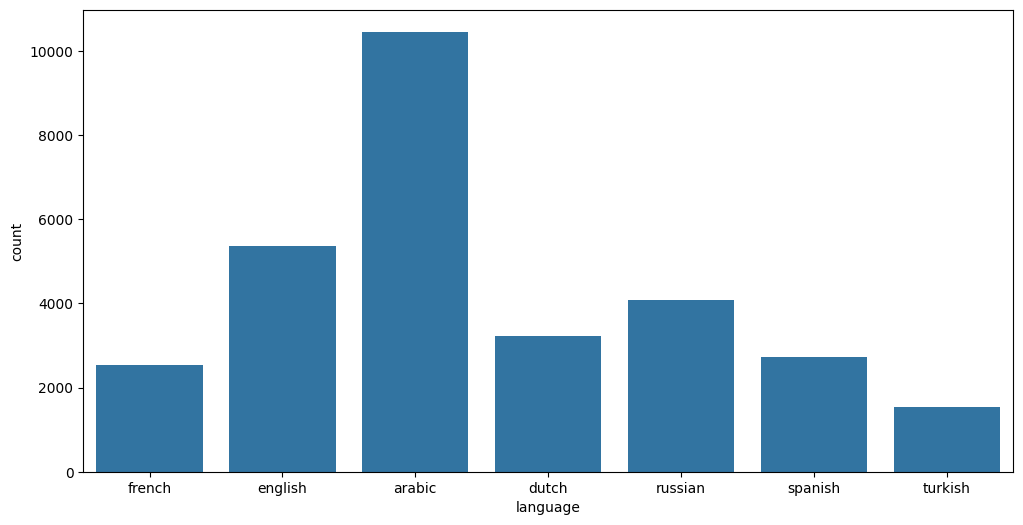

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(x='language',data=df)

In [15]:
df['sentence_id'].nunique()
df['review_id'].nunique()
df['category'].nunique()

33

In [16]:
df['polarity'].value_counts()
df.groupby('category')['polarity'].value_counts()

category                  polarity
ACCOMMODATION#DESIGN      positive    348
                          negative    252
                          neutral      40
ACCOMMODATION#EXPERIENCE  negative    654
                          positive    583
                                     ... 
SOFTWARE#PERFORMANCE      negative     16
                          neutral       2
SOFTWARE#USABILITY        positive     49
                          negative     24
                          neutral      11
Name: count, Length: 97, dtype: int64

In [17]:
df.isna().sum()

review_id         0
sentence_id       0
sentence          0
target         8948
category          0
polarity          0
language          0
dtype: int64

In [18]:
print("Class distribution:")
print(df['category'].value_counts())

Class distribution:
category
SERVICE#GENERAL                 5464
FOOD_DRINKS#QUALITY             5362
ACCOMMODATION#GENERAL           3118
RESTAURANT#GENERAL              2884
AMBIENCE#GENERAL                1928
FOOD_DRINKS#DESIGN              1505
LOCATION#GENERAL                1273
ACCOMMODATION#EXPERIENCE        1261
COMPUTING_DEVICE#GENERAL        1095
ACCOMMODATION#QUALITY            707
ACCOMMODATION#DESIGN             640
FOOD_DRINKS#PRICE                566
ACCOMMODATION#PRICE              515
COMPUTING_DEVICE#PERFORMANCE     500
RESTAURANT#PRICE                 480
COMPUTING_DEVICE#DESIGN          440
COMPUTING_DEVICE#QUALITY         400
COMPUTING_DEVICE#USABILITY       266
COMPUTING_DEVICE#PRICE           206
INPUT_DEVICES#GENERAL            199
SERVICE#QUALITY                  187
BATTERY#PERFORMANCE              159
SOFTWARE#GENERAL                 111
COMPANY#GENERAL                  109
DISPLAY#QUALITY                  103
SOFTWARE#USABILITY                84
HARDWARE#

Text(0.5, 1.0, 'Aspect Distribution')

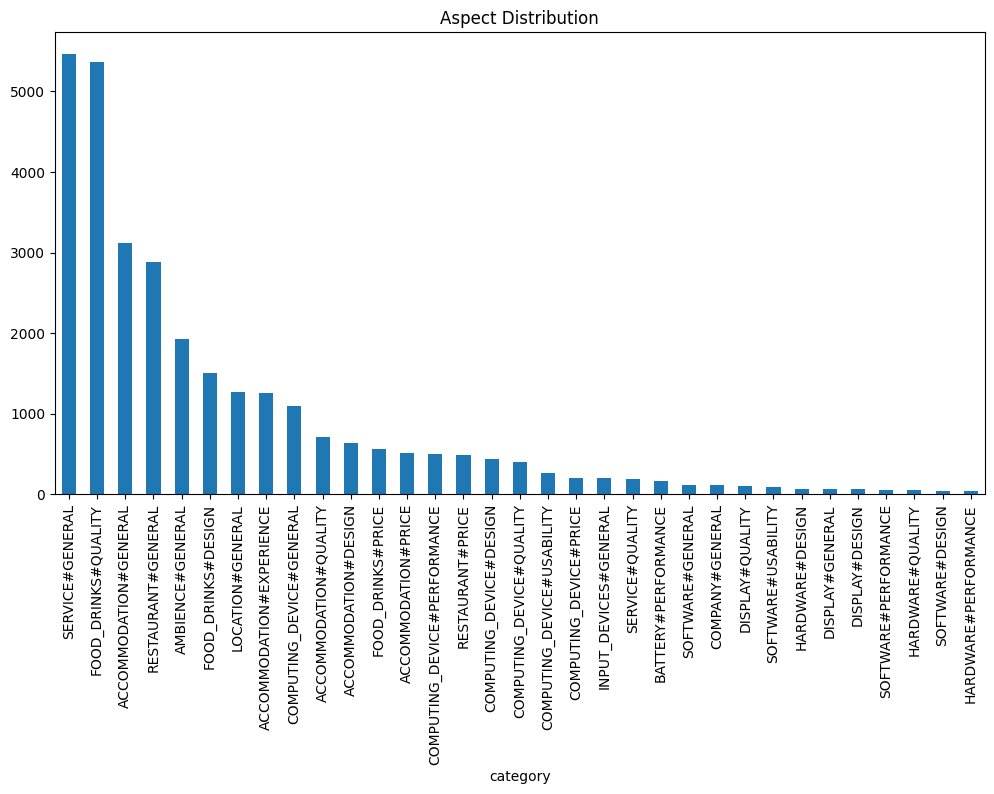

In [19]:
plt.figure(figsize=(12, 6))
df['category'].value_counts().plot(kind='bar')
plt.title('Aspect Distribution')

<Axes: >

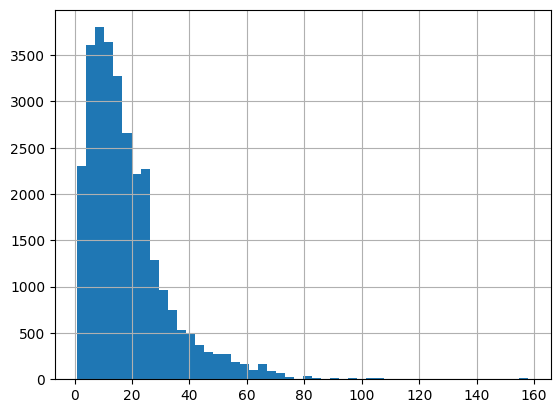

In [20]:
df['sentence_len'] = df['sentence'].apply(lambda x: len(x.split()))
df['sentence_len'].describe()
df['sentence_len'].hist(bins=50)

In [21]:
print("Class distribution:")
print(df['language'].value_counts())

Class distribution:
language
arabic     10458
english     5376
russian     4088
dutch       3231
spanish     2719
french      2530
turkish     1535
Name: count, dtype: int64


In [22]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))

# # KDE cho nhóm positive
# sns.kdeplot(df[df['polarity']=='positive']['Num_words_sentence'], 
#             shade=True, color='b', label='Positive')

# # KDE cho nhóm negative
# sns.kdeplot(df[df['polarity']=='negative']['Num_words_sentence'], 
#             shade=True, color='r', label='Negative')

# sns.kdeplot(df[df['polarity']=='neutral']['Num_words_sentence'], 
#             shade=True, color='g', label='Neutral')

# plt.title('Distribution of Number of Words by Polarity')
# plt.xlabel('Number of Words')
# plt.ylabel('Density')
# plt.legend()
# plt.show()

In [23]:
df['polarity'].value_counts()
df.groupby('category')['polarity'].value_counts()


category                  polarity
ACCOMMODATION#DESIGN      positive    348
                          negative    252
                          neutral      40
ACCOMMODATION#EXPERIENCE  negative    654
                          positive    583
                                     ... 
SOFTWARE#PERFORMANCE      negative     16
                          neutral       2
SOFTWARE#USABILITY        positive     49
                          negative     24
                          neutral      11
Name: count, Length: 97, dtype: int64

In [24]:
df['category'].nunique()

33

<Axes: xlabel='category', ylabel='count'>

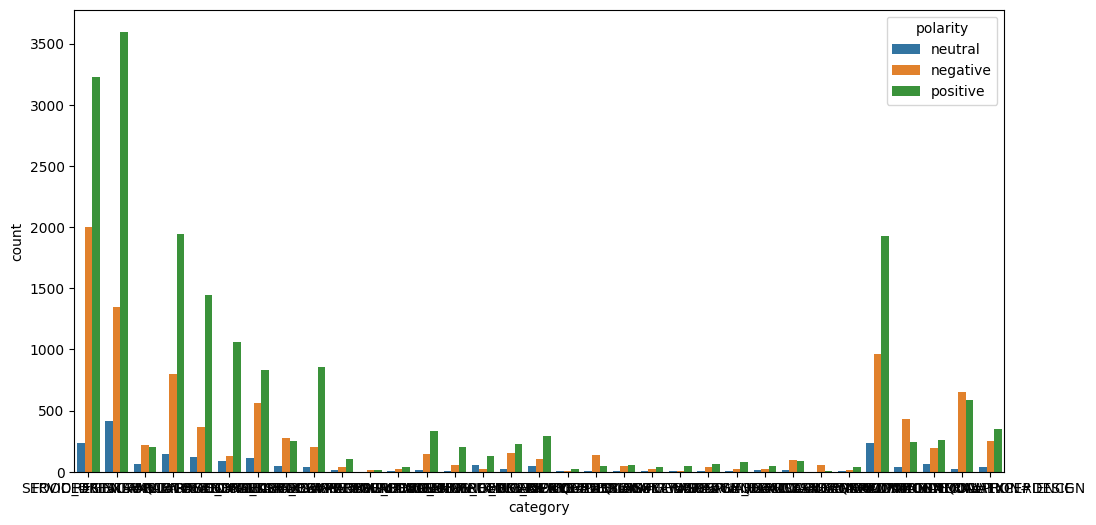

In [25]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='category', hue='polarity')

In [26]:
def clean_text(text: str) -> str:
    if isinstance(text, list) and len(text) > 0:
        text = text[0]
    elif not isinstance(text, str):
        text = str(text)

    # Xóa HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Xóa URL (http, https, www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Xóa emoji & ký tự đặc biệt Unicode
    emoji_pattern = re.compile("["  
        u"\U0001F600-\U0001F64F"  # emoticons  
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs  
        u"\U0001F680-\U0001F6FF"  # transport & map symbols  
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)  
        u"\U00002702-\U000027B0"  
        u"\U000024C2-\U0001F251"  
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub('', text)

    # Xóa dấu câu (chỉ giữ chữ, số, khoảng trắng)
    text = re.sub(r'[^\w\s]', '', text, flags=re.UNICODE)

    # Chuyển về chữ thường
    # text = text.lower()

    # Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text.strip())

    return text

In [27]:
df['sentence'] = df['sentence'].apply(clean_text)

In [28]:
df['temp_list'] = df['sentence'].apply(lambda x:str(x).split())
top = Counter([item for sublist in df['temp_list'] for item in sublist])
temp = pd.DataFrame(top.most_common(20))
temp.columns = ['Common_words','count']
temp.style.background_gradient(cmap='Blues')

,Common_words,count
0,في,6117
1,من,6017
2,de,5361
3,الفندق,4520
4,جدا,4065
5,و,3996
6,the,3584
7,en,3226
8,is,2973
9,a,2867


In [29]:
from sklearn.preprocessing import LabelEncoder

df['labels_category'] = df['category']
le_cat = LabelEncoder()
df['category_id'] = le_cat.fit_transform(df['labels_category'])
num_category = len(le_cat.classes_)

df['labels_polarity'] = df['polarity']
le_pol = LabelEncoder()
df['polarity_id'] = le_pol.fit_transform(df['labels_polarity'])
num_polarity = len(le_pol.classes_)

print(f"Number of category classes: {num_category}")
print(f"Number of polarity classes: {num_polarity}")

Number of category classes: 33
Number of polarity classes: 3


In [30]:
import random
from nltk.corpus import wordnet as wn

LANG_WORDNET_MAP = {
    "english": "eng",
    "arabic": "arb",
    "spanish": "spa",
    "french": "fra",
    "chinese": "cmn",
    "russian": None,
    "dutch": None,
    "turkish": None
}


def get_synonyms(word, lang_code):
    synonyms = set()
    for syn in wn.synsets(word, lang=lang_code):
        for lemma in syn.lemmas(lang=lang_code):
            name = lemma.name().replace("_", " ")
            if name.lower() != word.lower():
                synonyms.add(name)
    return list(synonyms)


def synonym_replacement_multilang(
    sentence,
    lang="english",
    n_replace=1,
    protected_words=None
):
    if protected_words is None:
        protected_words = []

    lang_code = LANG_WORDNET_MAP.get(lang)
    if lang_code is None:
        return sentence
    words = sentence.split()
    
    candidates = [
        w for w in words
        if w.lower() not in protected_words and w.isalpha()
    ]

    random.shuffle(candidates)
    replaced = 0

    new_words = words.copy()

    for word in candidates:
        synonyms = get_synonyms(word, lang_code)
        if synonyms:
            synonym = random.choice(synonyms)
            new_words = [
                synonym if w == word else w for w in new_words
            ]
            replaced += 1
        if replaced >= n_replace:
            break

    return " ".join(new_words)


In [31]:
text_en = "The hotel room is very clean"
text_fr = "La chambre est très propre"

print(synonym_replacement_multilang(
    text_en,
    lang="english",
    n_replace=2,
))

print(synonym_replacement_multilang(
    text_fr,
    lang="french",
    n_replace=1,
))


The hotel way comprise very clean
La chambre est très juste


In [32]:
# ===============================
# 3. Augmentation tools (BACK-TRANSLATION ONLY)
# ===============================
torch.manual_seed(SEED)

LANG_MAP = {
    "english": "en",
    "arabic": "ar",
    "russian": "ru",
    "dutch": "nl",
    "spanish": "es",
    "chinese": "zh",
    "french": "fr",
    "turkish": "tr"
}

# ===============================
# Translation model cache
# ===============================
MODEL_CACHE = {}

def load_translation_model(src_lang, tgt_lang):
    """
    Load MarianMT model with cache
    """
    key = f"{src_lang}-{tgt_lang}"
    if key in MODEL_CACHE:
        return MODEL_CACHE[key]

    model_name = f"Helsinki-NLP/opus-mt-{src_lang}-{tgt_lang}"
    tokenizer = MarianTokenizer.from_pretrained(model_name)
    model = MarianMTModel.from_pretrained(model_name)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()

    MODEL_CACHE[key] = (model, tokenizer)
    return model, tokenizer


def translate(texts, model, tokenizer):
    """
    Batch translation
    """
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=256)

    return [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]

def backtranslate(text, language):
    """
    Logic:
    - English      : EN -> VI -> EN
    - Non-English  : src -> EN -> src
    """
    try:
        src_lang = LANG_MAP.get(language.lower(), None)
        if src_lang is None:
            return text  # unsupported language

        # English → Vietnamese → English
        if src_lang == "en":
            model_1, tok_1 = load_translation_model("en", "vi")
            model_2, tok_2 = load_translation_model("vi", "en")

            vi_text = translate([text], model_1, tok_1)[0]
            back_text = translate([vi_text], model_2, tok_2)[0]

        # Other language → English → original language
        else:
            model_1, tok_1 = load_translation_model(src_lang, "en")
            model_2, tok_2 = load_translation_model("en", src_lang)

            en_text = translate([text], model_1, tok_1)[0]
            back_text = translate([en_text], model_2, tok_2)[0]

        return back_text

    except Exception:
        return text




In [33]:
def backtranslate_batch(texts, language, batch_size=32):
    src_lang = LANG_MAP.get(language.lower(), None)
    if src_lang is None:
        return texts

    try:
        # English → Vietnamese → English
        if src_lang == "en":
            m1, t1 = load_translation_model("en", "vi")
            m2, t2 = load_translation_model("vi", "en")
            bt_texts = []
            for i in range(0, len(texts), batch_size):
                batch = texts[i:i+batch_size]
                vi_text = translate(batch, m1, t1)
                back = translate(vi_text, m2, t2)
                bt_texts.extend(back)

        # Other → English → Other
        else:
            m1, t1 = load_translation_model(src_lang, "en")
            m2, t2 = load_translation_model("en", src_lang)
            bt_texts = []
            for i in range(0, len(texts), batch_size):
                batch = texts[i:i+batch_size]
                en_text = translate(batch, m1, t1)
                back = translate(en_text, m2, t2)
                bt_texts.extend(back)

        return bt_texts
    except Exception:
        return texts

In [34]:
def choose_augment_method(method_weights):
    methods = list(method_weights.keys())
    weights = list(method_weights.values())
    return random.choices(methods, weights=weights, k=1)[0]


In [35]:
def augment_sentence(sentence, language, method_weights, protected_words):
    methods = list(method_weights.keys())
    probs = list(method_weights.values())

    chosen_method = random.choices(methods, probs, k=1)[0]

    if chosen_method == "synonym":
        aug = synonym_replacement_multilang(
            sentence,
            lang=language,
            n_replace=1,
            protected_words=protected_words
        )
    elif chosen_method == "backtranslation":
        aug = backtranslate(sentence, language)
    else:
        aug = sentence

    return aug, chosen_method


In [36]:
def compute_quota(total, weights: dict):
    counts = {
        k: int(total * v) for k, v in weights.items()
    }
    diff = total - sum(counts.values())
    if diff > 0:
        first_key = list(counts.keys())[0]
        counts[first_key] += diff
    return counts


In [37]:
def get_target_for_category(cat_size):
    if cat_size < 500:
        return 800
    elif 500 <= cat_size < 1000:
        return 1500
    elif 1000 <= cat_size < 1500:
        return 1800
    elif 1500 <= cat_size < 3000:
        return 3200
    else:  
        return cat_size


In [38]:
# from collections import defaultdict
# import pandas as pd

# SYNONYM_SUPPORTED_LANGS = {"english", "french", "spanish", "german", "chinese"}

# def augment_by_category_polarity_language(
#     df,
#     polarity_weights={"neutral": 0.7, "negative": 0.3},
#     method_weights={"synonym": 0.7, "backtranslation": 0.3},
#     language_weights=None,
#     protected_words_by_category=None,
#     backtranslation_languages={"english", "french", "spanish", "arabic", "russian", "dutch", "chinese", "turkish"}
# ):
#     final_dfs = []
#     augment_stats = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))

#     POLARITY_FALLBACK = ["neutral", "negative", "positive"]

#     for category, cat_df in df.groupby("category"):
#         cat_size = len(cat_df)
#         target_per_category = get_target_for_category(cat_size)

#         print(f"\n[Category: {category}] size={cat_size} → target={target_per_category}")

#         # nếu đủ rồi thì giữ nguyên
#         if cat_size >= target_per_category:
#             final_dfs.append(cat_df)
#             continue

#         languages = cat_df["language"].unique()

#         # -------- LANGUAGE WEIGHTS --------
#         if language_weights is None:
#             lang_weights = {l: 1 / len(languages) for l in languages}
#         else:
#             lang_weights = {l: language_weights.get(l, 0) for l in languages if language_weights.get(l, 0) > 0}

#         total = sum(lang_weights.values())
#         lang_weights = {k: v / total for k, v in lang_weights.items()}

#         for lang, lang_df in cat_df.groupby("language"):
#             target_lang = int(target_per_category * lang_weights.get(lang, 0))
#             current = len(lang_df)
#             augment_needed = max(0, target_lang - current)

#             print(f"  └ {lang}: current={current}, target={target_lang}, augment={augment_needed}")

#             if augment_needed == 0:
#                 final_dfs.append(lang_df)
#                 continue

#             eligible_df = lang_df[lang_df["polarity"].isin(polarity_weights.keys())]
#             if eligible_df.empty:
#                 eligible_df = lang_df.copy()

#             # ===============================
#             # STEP 1: POLARITY QUOTA
#             # ===============================
#             polarity_quota = {}
#             remaining = augment_needed
#             for pol, pw in polarity_weights.items():
#                 polarity_quota[pol] = int(augment_needed * pw)
#                 remaining -= polarity_quota[pol]
#             if remaining > 0:
#                 max_pol = max(polarity_weights, key=polarity_weights.get)
#                 polarity_quota[max_pol] += remaining

#             # ===============================
#             # STEP 2: METHOD QUOTA
#             # ===============================
#             quota = defaultdict(dict)
#             for pol, pol_total in polarity_quota.items():
#                 rem = pol_total
#                 for method, mw in method_weights.items():
#                     quota[pol][method] = int(pol_total * mw)
#                     rem -= quota[pol][method]
#                 if rem > 0:
#                     max_method = max(method_weights, key=method_weights.get)
#                     quota[pol][max_method] += rem

#             print("    Quota:", dict(quota))

#             # ===============================
#             # AUGMENT
#             # ===============================
#             augmented_rows = []
#             used_sentences = set()
#             protected_words = protected_words_by_category.get(category, []) if protected_words_by_category else []

#             for polarity, methods in quota.items():
#                 pol_df = eligible_df[eligible_df["polarity"] == polarity]

#                 # Fallback polarity nếu lớp gốc không có sample
#                 fallback_idx = POLARITY_FALLBACK.index(polarity)
#                 while pol_df.empty and fallback_idx + 1 < len(POLARITY_FALLBACK):
#                     fallback_idx += 1
#                     fallback_pol = POLARITY_FALLBACK[fallback_idx]
#                     pol_df = eligible_df[eligible_df["polarity"] == fallback_pol]
#                     if not pol_df.empty:
#                         print(f"    Fallback {polarity} → {fallback_pol}")
#                         break

#                 if pol_df.empty:
#                     continue

#                 for method, n_samples in methods.items():
#                     if n_samples <= 0:
#                         continue

#                     for _ in range(n_samples):
#                         if len(augmented_rows) >= augment_needed:
#                             break

#                         row = pol_df.sample(1).iloc[0]

#                         if method == "synonym":
#                             if row["language"] not in SYNONYM_SUPPORTED_LANGS:
#                                 continue
#                             aug = synonym_replacement_multilang(
#                                 row["sentence"],
#                                 lang=row["language"],
#                                 n_replace=1,
#                                 protected_words=protected_words
#                             )
#                             if aug == row["sentence"] and row["language"] in backtranslation_languages:
#                                 aug = backtranslate(row["sentence"], row["language"])

#                         elif method == "backtranslation":
#                             if row["language"] not in backtranslation_languages:
#                                 continue
#                             aug = backtranslate(row["sentence"], row["language"])
#                         else:
#                             continue

#                         if aug == row["sentence"]:
#                             continue
#                         if aug in used_sentences:
#                             continue

#                         augmented_rows.append({**row, "sentence": aug, "augment_method": method})
#                         used_sentences.add(aug)
#                         augment_stats[category][lang][method] += 1

#             # ===============================
#             # FILL IF STILL MISSING
#             # ===============================
#             FALLBACK_METHODS = ["backtranslation"]
#             while len(augmented_rows) < augment_needed:
#                 row = eligible_df.sample(1).iloc[0]
#                 success = False
#                 for m in FALLBACK_METHODS:
#                     if m == "backtranslation" and row["language"] in backtranslation_languages:
#                         aug = backtranslate(row["sentence"], row["language"])
#                         if aug != row["sentence"]:
#                             augmented_rows.append({**row, "sentence": aug, "augment_method": m})
#                             augment_stats[category][lang][m] += 1
#                             success = True
#                             break
#                 if not success:
#                     augmented_rows.append({**row, "sentence": row["sentence"], "augment_method": "copy"})
#                     augment_stats[category][lang]["copy"] += 1

#             df_aug = pd.DataFrame(augmented_rows[:augment_needed])
#             final_dfs.append(pd.concat([lang_df, df_aug], ignore_index=True))

#     # ===============================
#     # REPORT
#     # ===============================
#     print("\n=== AUGMENT REPORT (REAL COUNT) ===")
#     for category, langs in augment_stats.items():
#         print(category)
#         for lang, methods in langs.items():
#             print(f" ├─ {lang}")
#             for m, c in methods.items():
#                 print(f" │   ├─ {m}: {c}")

#     return pd.concat(final_dfs, ignore_index=True)


In [ ]:
from collections import defaultdict
import pandas as pd

SYNONYM_SUPPORTED_LANGS = {"english", "french", "spanish", "german", "chinese", "arabic"}
def augment_by_category_polarity_language(
    df,
    polarity_weights={"neutral": 0.7, "negative": 0.3},
    method_weights={"synonym": 0.7, "backtranslation": 0.3},
    language_weights=None,
    protected_words_by_category=None,
    backtranslation_languages={"english", "french", "spanish", "arabic", "russian", "dutch", "chinese", "turkish"},
    batch_size=32
):
    final_dfs = []
    augment_stats = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    POLARITY_FALLBACK = ["neutral", "negative", "positive"]

    for category, cat_df in df.groupby("category"):
        cat_size = len(cat_df)
        target_per_category = get_target_for_category(cat_size)
        print(f"\n[Category: {category}] size={cat_size} → target={target_per_category}")

        if cat_size >= target_per_category:
            final_dfs.append(cat_df)
            continue

        languages = cat_df["language"].unique()
        if language_weights is None:
            lang_weights = {l: 1 / len(languages) for l in languages}
        else:
            lang_weights = {l: language_weights.get(l, 0) for l in languages if language_weights.get(l, 0) > 0}
        total = sum(lang_weights.values())
        lang_weights = {k: v / total for k, v in lang_weights.items()}

        for lang, lang_df in cat_df.groupby("language"):
            target_lang = int(target_per_category * lang_weights.get(lang, 0))
            current = len(lang_df)
            augment_needed = max(0, target_lang - current)
            print(f"  └ {lang}: current={current}, target={target_lang}, augment={augment_needed}")
            if augment_needed == 0:
                final_dfs.append(lang_df)
                continue

            eligible_df = lang_df[lang_df["polarity"].isin(polarity_weights.keys())]
            if eligible_df.empty:
                eligible_df = lang_df.copy()

            # ===============================
            # STEP 1: POLARITY QUOTA
            # ===============================
            polarity_quota = {}
            remaining = augment_needed
            for pol, pw in polarity_weights.items():
                polarity_quota[pol] = int(augment_needed * pw)
                remaining -= polarity_quota[pol]
            if remaining > 0:
                max_pol = max(polarity_weights, key=polarity_weights.get)
                polarity_quota[max_pol] += remaining

            # ===============================
            # STEP 2: METHOD QUOTA
            # ===============================
            quota = defaultdict(dict)
            for pol, pol_total in polarity_quota.items():
                rem = pol_total
                for method, mw in method_weights.items():
                    quota[pol][method] = int(pol_total * mw)
                    rem -= quota[pol][method]
                if rem > 0:
                    max_method = max(method_weights, key=method_weights.get)
                    quota[pol][max_method] += rem
            print("    Quota:", dict(quota))

            # ===============================
            # AUGMENT
            # ===============================
            augmented_rows = []
            used_sentences = set()
            protected_words = protected_words_by_category.get(category, []) if protected_words_by_category else []

            for polarity, methods in quota.items():
                pol_df = eligible_df[eligible_df["polarity"] == polarity]

                # fallback nếu không có sample
                fallback_idx = POLARITY_FALLBACK.index(polarity)
                while pol_df.empty and fallback_idx + 1 < len(POLARITY_FALLBACK):
                    fallback_idx += 1
                    fallback_pol = POLARITY_FALLBACK[fallback_idx]
                    pol_df = eligible_df[eligible_df["polarity"] == fallback_pol]
                    if not pol_df.empty:
                        print(f"    Fallback {polarity} → {fallback_pol}")
                        break
                if pol_df.empty:
                    continue

                for method, n_samples in methods.items():
                    if n_samples <= 0:
                        continue

                    # ===== SYNONYM =====
                    if method == "synonym":
                        candidates = pol_df.sample(n=min(n_samples, len(pol_df)), replace=True)
                        for _, row in candidates.iterrows():
                            if row["language"] not in SYNONYM_SUPPORTED_LANGS:
                                continue
                            aug = synonym_replacement_multilang(
                                row["sentence"], lang=row["language"],
                                n_replace=1, protected_words=protected_words
                            )
                            # fallback sang backtranslation nếu synonym không thay đổi
                            # if aug == row["sentence"] and row["language"] in backtranslation_languages:
                            #     aug = backtranslate(row["sentence"], row["language"])
                            # if aug == row["sentence"] or aug in used_sentences:
                            #     continue
                            augmented_rows.append({**row, "sentence": aug, "augment_method": method})
                            used_sentences.add(aug)
                            augment_stats[category][lang][method] += 1
                    # ===== BACKTRANSLATION =====
                    elif method == "backtranslation":
                        bt_candidates = pol_df.sample(n=min(n_samples, len(pol_df)), replace=True)
                        # nhóm theo ngôn ngữ và batch dịch
                        lang_groups = defaultdict(list)
                        for idx, row in bt_candidates.iterrows():
                            lang_groups[row["language"]].append((idx, row["sentence"]))
                        for l, items in lang_groups.items():
                            texts = [t for idx, t in items]
                            bt_texts = backtranslate_batch(texts, l, batch_size=batch_size)
                            for (idx, sentence), bt_text in zip(items, bt_texts):
                                if bt_text == sentence or bt_text in used_sentences:
                                    continue
                                # Nếu muốn giữ thông tin gốc từ df, bạn có thể lấy row gốc:
                                original_row = df.loc[idx]
                                augmented_rows.append({**original_row, "sentence": bt_text, "augment_method": "backtranslation"})
                                used_sentences.add(bt_text)
                                augment_stats[category][l][method] += 1

            # ===============================
            # FILL IF STILL MISSING
            # ===============================
            FALLBACK_METHODS = ["backtranslation"]
            while len(augmented_rows) < augment_needed:
                row = eligible_df.sample(1).iloc[0]
                success = False
                for m in FALLBACK_METHODS:
                    if m == "backtranslation" and row["language"] in backtranslation_languages:
                        aug = backtranslate(row["sentence"], row["language"])
                        if aug != row["sentence"]:
                            augmented_rows.append({**row, "sentence": aug, "augment_method": m})
                            augment_stats[category][lang][m] += 1
                            success = True
                            break
                if not success:
                    augmented_rows.append({**row, "sentence": row["sentence"], "augment_method": "copy"})
                    augment_stats[category][lang]["copy"] += 1

            df_aug = pd.DataFrame(augmented_rows[:augment_needed])
            final_dfs.append(pd.concat([lang_df, df_aug], ignore_index=True))

    # ===============================
    # REPORT
    # ===============================
    print("\n=== AUGMENT REPORT (REAL COUNT) ===")
    for category, langs in augment_stats.items():
        print(category)
        for lang, methods in langs.items():
            print(f" ├─ {lang}")
            for m, c in methods.items():
                print(f" │   ├─ {m}: {c}")

    return pd.concat(final_dfs, ignore_index=True)


In [40]:
# df_aug = augment_by_category_polarity_language(
#     df,
#     polarity_weights={"neutral": 0.8, "negative": 0.2},
#     method_weights={"synonym": 0.8, "backtranslation": 0.2},
#     # method_weights=None,
#     language_weights=None,
#     protected_words_by_category=None,
    
# )



In [ ]:
df_aug = pd.read_csv(r"/kaggle/input/new-data/New_data/csv/augmented_dataset_final.csv")

In [5]:
print("\n=== Augmentation Statistics ===")
print("\n Data augmentation done!")
print("Train original:", df.shape)
print("Augmented:", df_aug.shape)
print("Label distribution:")
print(df_aug['category'].value_counts())
print("Class distribution:")
pretty_counts.index.name = "polarity"
print(pretty_counts)


=== Augmentation Statistics ===

 Data augmentation done!
Train original: (29937, 7)
Augmented: (82270, 12)
Label distribution:
category
SERVICE#GENERAL                 5465
FOOD_DRINKS#QUALITY             5362
RESTAURANT#GENERAL              3427
AMBIENCE#GENERAL                3375
FOOD_DRINKS#DESIGN              3199
ACCOMMODATION#GENERAL           3118
ACCOMMODATION#PRICE             2800
ACCOMMODATION#EXPERIENCE        2800
ACCOMMODATION#DESIGN            2800
ACCOMMODATION#QUALITY           2800
COMPUTING_DEVICE#DESIGN         2799
COMPUTING_DEVICE#PERFORMANCE    2799
COMPUTING_DEVICE#GENERAL        2799
COMPUTING_DEVICE#QUALITY        2799
LOCATION#GENERAL                2629
FOOD_DRINKS#PRICE               1799
CAMERA#QUALITY                  1500
COMPANY#GENERAL                 1500
CAMERA#GENERAL                  1500
CAMERA#DESIGN                   1500
BATTERY#PERFORMANCE             1500
DISPLAY#QUALITY                 1500
DISPLAY#GENERAL                 1500
DISPLAY#DES

In [6]:
df_aug.shape

(82270, 12)

<Axes: xlabel='language', ylabel='count'>

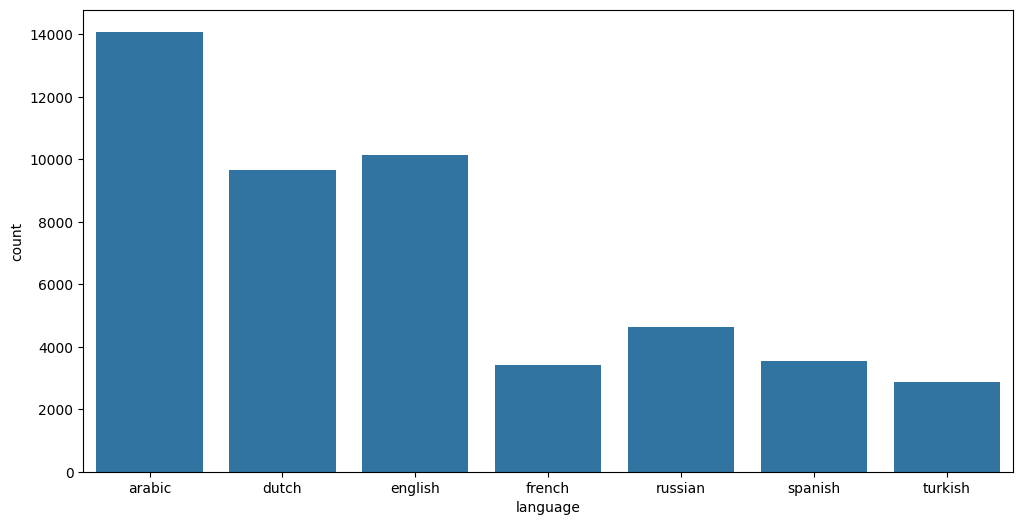

In [52]:
plt.figure(figsize=(12,6))
sns.countplot(x='language',data=df_aug)

In [53]:
# Fit LabelEncoders on final augmented dataset
from sklearn.preprocessing import LabelEncoder

le_cat = LabelEncoder()
le_pol = LabelEncoder()

le_cat.fit(df_aug['category'].astype(str).tolist())
le_pol.fit(df_aug['polarity'].astype(str).tolist())

# Recompute category_id and polarity_id from these encoders (overwrite to be consistent)
df_aug['category_id'] = le_cat.transform(df_aug['category'].astype(str).tolist())
df_aug['polarity_id'] = le_pol.transform(df_aug['polarity'].astype(str).tolist())

In [54]:
# After re-encoding, confirm round-trip and no missing ids
assert set(le_cat.inverse_transform(range(len(le_cat.classes_)))) == set(le_cat.classes_)
print("le_cat classes:", len(le_cat.classes_), le_cat.classes_)
print("le_pol classes:", len(le_pol.classes_), le_pol.classes_)
print("Any NaNs in ids:", df_aug['category_id'].isna().sum(), df_aug['polarity_id'].isna().sum())

le_cat classes: 33 ['ACCOMMODATION#DESIGN' 'ACCOMMODATION#EXPERIENCE' 'ACCOMMODATION#GENERAL'
 'ACCOMMODATION#PRICE' 'ACCOMMODATION#QUALITY' 'AMBIENCE#GENERAL'
 'BATTERY#PERFORMANCE' 'COMPANY#GENERAL' 'COMPUTING_DEVICE#DESIGN'
 'COMPUTING_DEVICE#GENERAL' 'COMPUTING_DEVICE#PERFORMANCE'
 'COMPUTING_DEVICE#PRICE' 'COMPUTING_DEVICE#QUALITY'
 'COMPUTING_DEVICE#USABILITY' 'DISPLAY#DESIGN' 'DISPLAY#GENERAL'
 'DISPLAY#QUALITY' 'FOOD_DRINKS#DESIGN' 'FOOD_DRINKS#PRICE'
 'FOOD_DRINKS#QUALITY' 'HARDWARE#DESIGN' 'HARDWARE#PERFORMANCE'
 'HARDWARE#QUALITY' 'INPUT_DEVICES#GENERAL' 'LOCATION#GENERAL'
 'RESTAURANT#GENERAL' 'RESTAURANT#PRICE' 'SERVICE#GENERAL'
 'SERVICE#QUALITY' 'SOFTWARE#DESIGN' 'SOFTWARE#GENERAL'
 'SOFTWARE#PERFORMANCE' 'SOFTWARE#USABILITY']
le_pol classes: 3 ['negative' 'neutral' 'positive']
Any NaNs in ids: 0 0


In [55]:
train_df, test_df = train_test_split(
    df_aug,
    test_size=0.2,
    stratify=df_aug[['category', 'polarity']].astype(str).agg('_'.join, axis=1),
    random_state=SEED
)

In [56]:
df_aug.head()

,review_id,sentence_id,sentence,target,category,polarity,language,sentence_len,temp_list,labels_category,category_id,labels_polarity,polarity_id,augment_method
0,1210,1210:2,شاطئ البحر خرافي مع بحيرة صناعية واسماك حولك و...,شاطئ البحر,ACCOMMODATION#DESIGN,positive,arabic,10,"['شاطئ', 'البحر', 'خرافي', 'مع', 'بحيرة', 'صنا...",ACCOMMODATION#DESIGN,0,positive,2,NaN
1,1705,1705:1,الغرف رائعة الكثير من مساحة كبيرة بحجم ملكي لل...,الغرف,ACCOMMODATION#DESIGN,positive,arabic,14,"['الغرف', 'رائعة', 'الكثير', 'من', 'مساحة', 'ك...",ACCOMMODATION#DESIGN,0,positive,2,NaN
2,1705,1705:2,لقد تم تصوير فيلم قصير هنا كانت الغرفة في الطا...,الغرفة,ACCOMMODATION#DESIGN,positive,arabic,27,"['لقد', 'تم', 'تصوير', 'فيلم', 'قصير', 'هنا', ...",ACCOMMODATION#DESIGN,0,positive,2,NaN
3,1017,1017:0,لقد كرهناه ولن نعود أبدا الاستوديوهات بمقاس ال...,الاستوديوهات,ACCOMMODATION#DESIGN,negative,arabic,9,"['لقد', 'كرهناه', 'ولن', 'نعود', 'أبدا', 'الاس...",ACCOMMODATION#DESIGN,0,negative,0,NaN
4,1017,1017:0,لقد كرهناه ولن نعود أبدا الاستوديوهات بمقاس ال...,NaN,ACCOMMODATION#DESIGN,negative,arabic,9,"['لقد', 'كرهناه', 'ولن', 'نعود', 'أبدا', 'الاس...",ACCOMMODATION#DESIGN,0,negative,0,NaN


In [57]:
df_aug['category_id'] = df_aug['category_id'].astype(int)
df_aug['polarity_id'] = df_aug['polarity_id'].astype(int)

In [58]:
print(df_aug['category_id'].isna().sum())
print(df_aug['polarity_id'].isna().sum())

0
0


In [59]:
train_df.head()

,review_id,sentence_id,sentence,target,category,polarity,language,sentence_len,temp_list,labels_category,category_id,labels_polarity,polarity_id,augment_method
22006,Review-g188671-d1761224_3,Review-g188671-d1761224_3:1,Het restaurant heeft een beperkt menu maar all...,restaurant,FOOD_DRINKS#DESIGN,negative,dutch,13,"['her', 'restaurant', 'heeft', 'een', 'beperkt...",FOOD_DRINKS#DESIGN,17,negative,0,backtranslation
484,1324,1324:2,الغرفه مكونه من مطبخ بسيط و حمام وسرير ومكتبة ...,مطبخ,ACCOMMODATION#DESIGN,positive,arabic,28,"['الغرفه', 'مكونه', 'من', 'مطبخ', 'بسيط', 'و',...",ACCOMMODATION#DESIGN,0,positive,2,NaN
26099,g187147-d3412675-r163663857,g187147-d3412675-r163663857:0,Si vous voulez vous régaler de la mise en bouc...,NaN,FOOD_DRINKS#QUALITY,positive,french,25,"['Si', 'vous', 'voulez', 'vous', 'régaler', 'd...",FOOD_DRINKS#QUALITY,19,positive,2,NaN
20902,348,348:1,The only thing I dont understand is that the r...,NaN,DISPLAY#QUALITY,negative,english,22,"['The', 'only', 'thing', 'I', 'dont', 'underst...",DISPLAY#QUALITY,16,negative,0,NaN
43241,1850,1850:3,الأثاث قديم جدا والخدمة سيئة ولا أنصح أحد بالإ...,الخدمة,SERVICE#GENERAL,negative,arabic,10,"['الأثاث', 'قديم', 'جدا', 'والخدمة', 'سيئة', '...",SERVICE#GENERAL,27,negative,0,NaN


In [60]:
df_aug.to_csv("df_aug_clean.csv", index=False, encoding="utf-8")

In [61]:
train_df['category_id'] = train_df['category_id'].astype(int)
train_df['polarity_id'] = train_df['polarity_id'].astype(int)


In [62]:
train_df.head()

,review_id,sentence_id,sentence,target,category,polarity,language,sentence_len,temp_list,labels_category,category_id,labels_polarity,polarity_id,augment_method
22006,Review-g188671-d1761224_3,Review-g188671-d1761224_3:1,Het restaurant heeft een beperkt menu maar all...,restaurant,FOOD_DRINKS#DESIGN,negative,dutch,13,"['her', 'restaurant', 'heeft', 'een', 'beperkt...",FOOD_DRINKS#DESIGN,17,negative,0,backtranslation
484,1324,1324:2,الغرفه مكونه من مطبخ بسيط و حمام وسرير ومكتبة ...,مطبخ,ACCOMMODATION#DESIGN,positive,arabic,28,"['الغرفه', 'مكونه', 'من', 'مطبخ', 'بسيط', 'و',...",ACCOMMODATION#DESIGN,0,positive,2,NaN
26099,g187147-d3412675-r163663857,g187147-d3412675-r163663857:0,Si vous voulez vous régaler de la mise en bouc...,NaN,FOOD_DRINKS#QUALITY,positive,french,25,"['Si', 'vous', 'voulez', 'vous', 'régaler', 'd...",FOOD_DRINKS#QUALITY,19,positive,2,NaN
20902,348,348:1,The only thing I dont understand is that the r...,NaN,DISPLAY#QUALITY,negative,english,22,"['The', 'only', 'thing', 'I', 'dont', 'underst...",DISPLAY#QUALITY,16,negative,0,NaN
43241,1850,1850:3,الأثاث قديم جدا والخدمة سيئة ولا أنصح أحد بالإ...,الخدمة,SERVICE#GENERAL,negative,arabic,10,"['الأثاث', 'قديم', 'جدا', 'والخدمة', 'سيئة', '...",SERVICE#GENERAL,27,negative,0,NaN


In [63]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class BERTMultiTaskDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128, text_col='sentence'):

        self.texts = df[text_col].fillna("").tolist()
        self.labels_category = df['category_id'].astype(int).tolist()
        self.labels_polarity = df['polarity_id'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        category_label = int(self.labels_category[idx])
        polarity_label = int(self.labels_polarity[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),       # [seq_len]
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels_category': torch.tensor(category_label, dtype=torch.long),
            'labels_polarity': torch.tensor(polarity_label, dtype=torch.long)
        }


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.W = nn.Linear(hidden_size, hidden_size)
        self.u = nn.Linear(hidden_size, 1, bias=False)
        self.dropout = nn.Dropout(p=0.1)
    
    def forward(self, x):
        # x: (batch, seq_len, hidden_size)
        u_it = torch.tanh(self.W(x))                 # (batch, seq_len, hidden_size)
        a_it = self.u(u_it).squeeze(-1)              # (batch, seq_len)
        a_it = F.softmax(a_it, dim=1).unsqueeze(-1)  # (batch, seq_len, 1)
        a_it = self.dropout(a_it)                    # apply dropout
        weighted_input = x * a_it
        return weighted_input.sum(dim=1)             # (batch, hidden_size)


In [65]:
from transformers import AutoModel
import torch.nn as nn
import torch.nn.functional as F

NUM_CLASSES = 33
class BERT_BiLSTM_Attention_MultiTask(nn.Module):
    def __init__(self, bert_model_name, lstm_hidden=64, 
                 num_category_classes=NUM_CLASSES, num_polarity_classes=3, dropout=0.3):
        super(BERT_BiLSTM_Attention_MultiTask, self).__init__()
        
        # mBERT
        self.bert = AutoModel.from_pretrained(bert_model_name)
        
        # Freeze một số layer BERT đầu để tránh overfitting
        for param in self.bert.embeddings.parameters():
            param.requires_grad = False
            
        # for param in self.bert.encoder.layer[:4].parameters():
        #     param.requires_grad = False
            
        hidden_size = self.bert.config.hidden_size
        
        # BiLSTM 2 layers
        self.lstm = nn.LSTM(hidden_size, lstm_hidden, 
                           batch_first=True, bidirectional=True, 
                           dropout=dropout, num_layers=2)
        
        # Attention
        self.attention = Attention(lstm_hidden*2)
        
        # BatchNorm
        self.batch_norm = nn.BatchNorm1d(lstm_hidden*2)
        
        # Shared classifier layers
        self.fc1 = nn.Linear(lstm_hidden*2, 128)
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(dropout)
        
        # Multi-task heads
        self.fc_category = nn.Linear(64, num_category_classes)
        self.fc_polarity = nn.Linear(64, num_polarity_classes)
    
    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_output.last_hidden_state               # (batch, seq_len, hidden_size)
        x, _ = self.lstm(x)                            # BiLSTM
        x = self.attention(x)                          # Attention
        x = self.batch_norm(x)                         # BatchNorm
        
        # Shared MLP
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        
        # Multi-task outputs
        out_category = self.fc_category(x)
        out_polarity = self.fc_polarity(x)
        
        return out_category, out_polarity

In [66]:
train_df['category_id'] = train_df['category_id'].fillna(-1).astype(int)
train_df['polarity_id'] = train_df['polarity_id'].fillna(-1).astype(int)

test_df['category_id'] = test_df['category_id'].fillna(-1).astype(int)
test_df['polarity_id'] = test_df['polarity_id'].fillna(-1).astype(int)


In [67]:
from torch.utils.data import Dataset, DataLoader, random_split
full_dataset = BERTMultiTaskDataset(train_df, tokenizer)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
test_dataset = BERTMultiTaskDataset(test_df, tokenizer)

In [68]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

In [69]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
import os
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_score, model):
        if self.best_score is None:
            self.best_score = val_score
            if self.restore_best_weights:
                self.best_weights = model.state_dict().copy()
        elif val_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                if self.restore_best_weights and self.best_weights:
                    model.load_state_dict(self.best_weights)
                return True
        else:
            self.best_score = val_score
            self.counter = 0
            if self.restore_best_weights:
                self.best_weights = model.state_dict().copy()
        return False

In [70]:
def save_checkpoint(model, optimizer, epoch, loss, filename):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'le_cat_classes': le_cat.classes_.tolist(),
        'le_pol_classes': le_pol.classes_.tolist()
    }, filename)
    print(f"Checkpoint saved: {filename}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [71]:
device = DEVICE
def evaluate_multitask(model, data_loader, device):
    model.eval()
    cat_labels, cat_preds, cat_probs = [], [], []
    pol_labels, pol_preds, pol_probs = [], [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            labels_cat = batch['labels_category'].to(device)
            labels_pol = batch['labels_polarity'].to(device)

            outputs_cat, outputs_pol = model(input_ids, attention_mask)

            probs_cat = F.softmax(outputs_cat, dim=1)
            preds_cat = torch.argmax(probs_cat, dim=1)

            probs_pol = F.softmax(outputs_pol, dim=1)
            preds_pol = torch.argmax(probs_pol, dim=1)

            cat_labels.extend(labels_cat.cpu().numpy())
            cat_preds.extend(preds_cat.cpu().numpy())
            cat_probs.extend(probs_cat.cpu().numpy())

            pol_labels.extend(labels_pol.cpu().numpy())
            pol_preds.extend(preds_pol.cpu().numpy())
            pol_probs.extend(probs_pol.cpu().numpy())

    return (cat_labels, cat_preds, cat_probs), (pol_labels, pol_preds, pol_probs)



In [72]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

def build_optimizer(model):
    return AdamW([
        {"params": model.bert.embeddings.parameters(), "lr": 5e-6},
        {"params": model.bert.encoder.parameters(), "lr": 2e-5},
        {"params": model.lstm.parameters(), "lr": 1e-3},
        {"params": model.fc1.parameters(), "lr": 1e-3},
        {"params": model.fc2.parameters(), "lr": 1e-3},
        {"params": model.fc_category.parameters(), "lr": 1e-3},
        {"params": model.fc_polarity.parameters(), "lr": 1e-3},
    ], weight_decay=0.01)


In [73]:
model = BERT_BiLSTM_Attention_MultiTask(MODEL_NAME).to(device)

# # Check if data is balanced after augmentation
# print("Data distribution after augmentation:")
# print(train_aug['label'].value_counts().sort_index())
# print("Data is balanced - using standard CrossEntropyLoss")

optimizer = build_optimizer(model)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
criterion = nn.CrossEntropyLoss()

from sklearn.metrics import f1_score, accuracy_score

def train_enhanced(model, train_loader, val_loader, epochs):
    early_stopping = EarlyStopping(patience=3)
    train_losses = []
    val_losses = []
    train_f1_category = []
    train_f1_polarity = []
    val_f1_category = []
    val_f1_polarity = []
    train_acc_category = []
    train_acc_polarity = []
    val_acc_category = []
    val_acc_polarity = []
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        val_loss_total = 0
        train_preds_cat, train_preds_pol = [], []
        train_labels_cat, train_labels_pol = [], []
        
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_category = batch['labels_category'].to(device)
            labels_polarity = batch['labels_polarity'].to(device)

            out_category, out_polarity = model(input_ids, attention_mask)
            
            loss_cat = criterion(out_category, labels_category)
            loss_pol = criterion(out_polarity, labels_polarity)
            loss = loss_cat + loss_pol
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            
            # Track predictions and labels
            train_preds_cat.extend(torch.argmax(out_category, dim=1).cpu().numpy())
            train_preds_pol.extend(torch.argmax(out_polarity, dim=1).cpu().numpy())
            train_labels_cat.extend(labels_category.cpu().numpy())
            train_labels_pol.extend(labels_polarity.cpu().numpy())
        
        avg_train_loss = total_loss / len(train_loader)
        train_f1_cat = f1_score(train_labels_cat, train_preds_cat, average='weighted')
        train_f1_pol = f1_score(train_labels_pol, train_preds_pol, average='weighted')
        train_losses.append(avg_train_loss)

        # Train accuracy
        acc_train_cat = accuracy_score(train_labels_cat, train_preds_cat)
        acc_train_pol = accuracy_score(train_labels_pol, train_preds_pol)
        train_acc_category.append(acc_train_cat)
        train_acc_polarity.append(acc_train_pol)
        
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}, "
              f"Train F1 Category: {train_f1_cat:.4f}, Train Acc Category: {acc_train_cat:.4f}, "
              f"Train F1 Polarity: {train_f1_pol:.4f}, Train Acc Polarity: {acc_train_pol:.4f}")
        
        # Validation phase
        val_labels_cat, val_labels_pol, val_preds_cat, val_preds_pol = [], [], [], []
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels_category = batch['labels_category'].to(device)
                labels_polarity = batch['labels_polarity'].to(device)

                out_category, out_polarity = model(input_ids, attention_mask)
                loss_cat = criterion(out_category, labels_category)
                loss_pol = criterion(out_polarity, labels_polarity)
                loss = loss_cat + loss_pol

                val_loss_total += loss.item()
                val_preds_cat.extend(torch.argmax(out_category, dim=1).cpu().numpy())
                val_preds_pol.extend(torch.argmax(out_polarity, dim=1).cpu().numpy())
                val_labels_cat.extend(labels_category.cpu().numpy())
                val_labels_pol.extend(labels_polarity.cpu().numpy())
        avg_val_loss = val_loss_total / len(val_loader)
        val_losses.append(avg_val_loss)
        f1_val_cat = f1_score(val_labels_cat, val_preds_cat, average='weighted')
        f1_val_pol = f1_score(val_labels_pol, val_preds_pol, average='weighted')
        val_f1_category.append(f1_val_cat)
        val_f1_polarity.append(f1_val_pol)

        # Validation accuracy
        acc_val_cat = accuracy_score(val_labels_cat, val_preds_cat)
        acc_val_pol = accuracy_score(val_labels_pol, val_preds_pol)
        val_acc_category.append(acc_val_cat)
        val_acc_polarity.append(acc_val_pol)
        
        train_f1_category.append(train_f1_cat)
        train_f1_polarity.append(train_f1_pol)

        print(f"Val Loss: {avg_val_loss:.4f}, "
              f"Val F1 Category: {f1_val_cat:.4f}, Val Acc Category: {acc_val_cat:.4f}, "
              f"Val F1 Polarity: {f1_val_pol:.4f}, Val Acc Polarity: {acc_val_pol:.4f}")

        # Scheduler
        scheduler.step((f1_val_cat + f1_val_pol)/2)
        
        # Save checkpoint
        if len(val_f1_category) == 1 or f1_val_cat > max(val_f1_category[:-1]):
            save_checkpoint(model, optimizer, epoch, avg_train_loss, 
                            f'/kaggle/working/best_model_checkpoint.pth')
        
        # Early stopping
        if early_stopping(f1_val_cat, model):
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        print("-" * 50)
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_f1_category': train_f1_category,
        'train_f1_polarity': train_f1_polarity,
        'train_acc_category': train_acc_category,
        'train_acc_polarity': train_acc_polarity,
        'val_f1_category': val_f1_category,
        'val_f1_polarity': val_f1_polarity,
        'val_acc_category': val_acc_category,
        'val_acc_polarity': val_acc_polarity
    }

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [74]:
# Use the enhanced training function
def train(model, train_loader, val_loader, epochs):
    return train_enhanced(model, train_loader, val_loader, epochs)

In [75]:
from sklearn.metrics import roc_curve, auc, roc_auc_score


def plot_roc(all_labels, all_probs, num_classes=NUM_CLASSES):
    y_bin = np.eye(num_classes)[all_labels]
    plt.figure(figsize=(10, 8))
    auc_list = []
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], np.array(all_probs)[:, i])
        roc_auc = auc(fpr, tpr)
        auc_list.append(roc_auc)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")
    
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Multi-class | Macro AUC={np.mean(auc_list):.2f}")
    plt.legend()
    plt.show()


In [76]:
# ===============================
# 10. Run Training + Test
# ===============================
metrics = train(model, train_loader, val_loader, EPOCHS)

Epoch 1/20
Train Loss: 2.9327, Train F1 Category: 0.2864, Train Acc Category: 0.3031, Train F1 Polarity: 0.6402, Train Acc Polarity: 0.6683
Val Loss: 2.2445, Val F1 Category: 0.4307, Val Acc Category: 0.4494, Val F1 Polarity: 0.7397, Val Acc Polarity: 0.7503
Checkpoint saved: /kaggle/working/best_model_checkpoint.pth
--------------------------------------------------
Epoch 2/20
Train Loss: 2.2550, Train F1 Category: 0.4445, Train Acc Category: 0.4537, Train F1 Polarity: 0.7610, Train Acc Polarity: 0.7685
Val Loss: 1.9300, Val F1 Category: 0.4951, Val Acc Category: 0.5119, Val F1 Polarity: 0.8023, Val Acc Polarity: 0.8080
Checkpoint saved: /kaggle/working/best_model_checkpoint.pth
--------------------------------------------------
Epoch 3/20
Train Loss: 1.9509, Train F1 Category: 0.5039, Train Acc Category: 0.5102, Train F1 Polarity: 0.8204, Train Acc Polarity: 0.8232
Val Loss: 1.8600, Val F1 Category: 0.5312, Val Acc Category: 0.5400, Val F1 Polarity: 0.8110, Val Acc Polarity: 0.8133
C

In [77]:
import pickle

with open("/kaggle/working/training_metrics_mBERT.pkl", "wb") as f:
    pickle.dump(metrics, f)


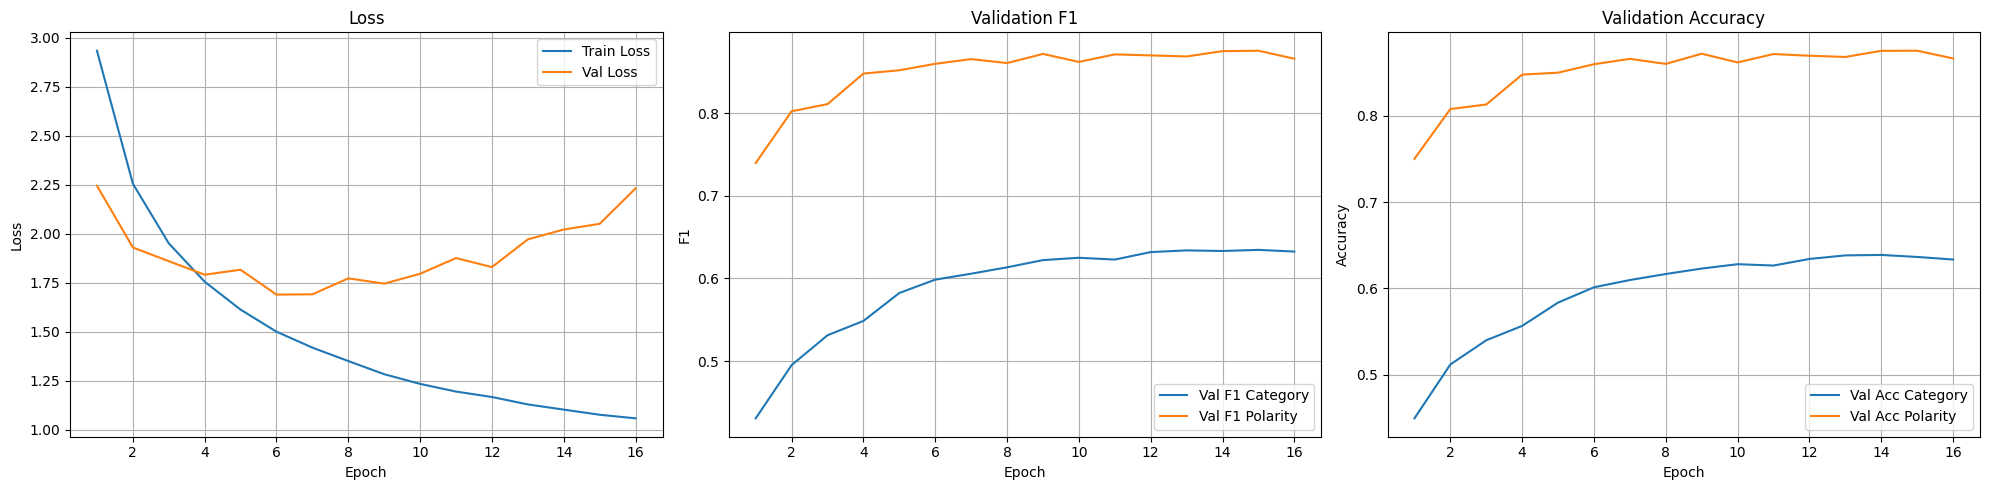

In [7]:
import pickle
import matplotlib.pyplot as plt

file_path = r'D:\2025-2026\ChuyenDe\pkl\mbert-freeze-emb.pkl'

try:
    with open(file_path, "rb") as f:
        metrics = pickle.load(f)
except FileNotFoundError:
    print(f"❌ Không tìm thấy file tại: {file_path}")
    metrics = None
except Exception as e:
    print(f"❌ Lỗi khi đọc file: {e}")
    metrics = None


def plot_training_history_full(metrics):
    epochs = range(1, len(metrics["train_losses"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # ===== Loss =====
    axes[0].plot(epochs, metrics["train_losses"], label="Train Loss")
    axes[0].plot(epochs, metrics["val_losses"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # ===== F1 =====
    axes[1].plot(epochs, metrics["val_f1_category"], label="Val F1 Category")
    axes[1].plot(epochs, metrics["val_f1_polarity"], label="Val F1 Polarity")
    axes[1].set_title("Validation F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1")
    axes[1].legend()
    axes[1].grid(True)

    # ===== Accuracy =====
    axes[2].plot(epochs, metrics["val_acc_category"], label="Val Acc Category")
    axes[2].plot(epochs, metrics["val_acc_polarity"], label="Val Acc Polarity")
    axes[2].set_title("Validation Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Accuracy")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()
plot_training_history_full(metrics)

In [79]:
import torch
from sklearn.metrics import classification_report

def evaluate_classification_report_multitask(model, test_loader, device):
    model.eval()

    all_labels_cat, all_preds_cat = [], []
    all_labels_pol, all_preds_pol = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_cat = batch['labels_category'].to(device)
            labels_pol = batch['labels_polarity'].to(device)

            out_cat, out_pol = model(input_ids, attention_mask)

            preds_cat = torch.argmax(out_cat, dim=1)
            preds_pol = torch.argmax(out_pol, dim=1)

            all_labels_cat.extend(labels_cat.cpu().numpy())
            all_preds_cat.extend(preds_cat.cpu().numpy())
            all_labels_pol.extend(labels_pol.cpu().numpy())
            all_preds_pol.extend(preds_pol.cpu().numpy())

    print("========== CATEGORY ==========")
    print(classification_report(
        all_labels_cat, all_preds_cat, digits=4
    ))

    print("========== POLARITY ==========")
    print(classification_report(
        all_labels_pol, all_preds_pol, digits=4
    ))

    return (
        all_labels_cat, all_preds_cat
    ), (
        all_labels_pol, all_preds_pol
    )

# Gọi hàm
(category_labels, category_preds), (polarity_labels, polarity_preds) = \
    evaluate_classification_report_multitask(
        model, test_loader, device
    )



========== CATEGORY ==========
              precision    recall  f1-score   support

           0     0.5924    0.6179    0.6049       301
           1     0.4393    0.4722    0.4552       360
           2     0.4142    0.4295    0.4217       624
           3     0.6000    0.6823    0.6385       299
           4     0.6075    0.4333    0.5058       300
           5     0.6744    0.7733    0.7205       675
           6     0.8788    0.8208    0.8488       106
           7     0.7653    0.9375    0.8427       160
           8     0.5138    0.6500    0.5740       200
           9     0.6085    0.5688    0.5880       276
          10     0.6793    0.6250    0.6510       200
          11     0.5826    0.6262    0.6036       107
          12     0.5804    0.6500    0.6132       200
          13     0.7101    0.4623    0.5600       106
          14     0.7815    0.8692    0.8230       107
          15     0.6357    0.7664    0.6949       107
          16     0.7922    0.5755    0.6667       

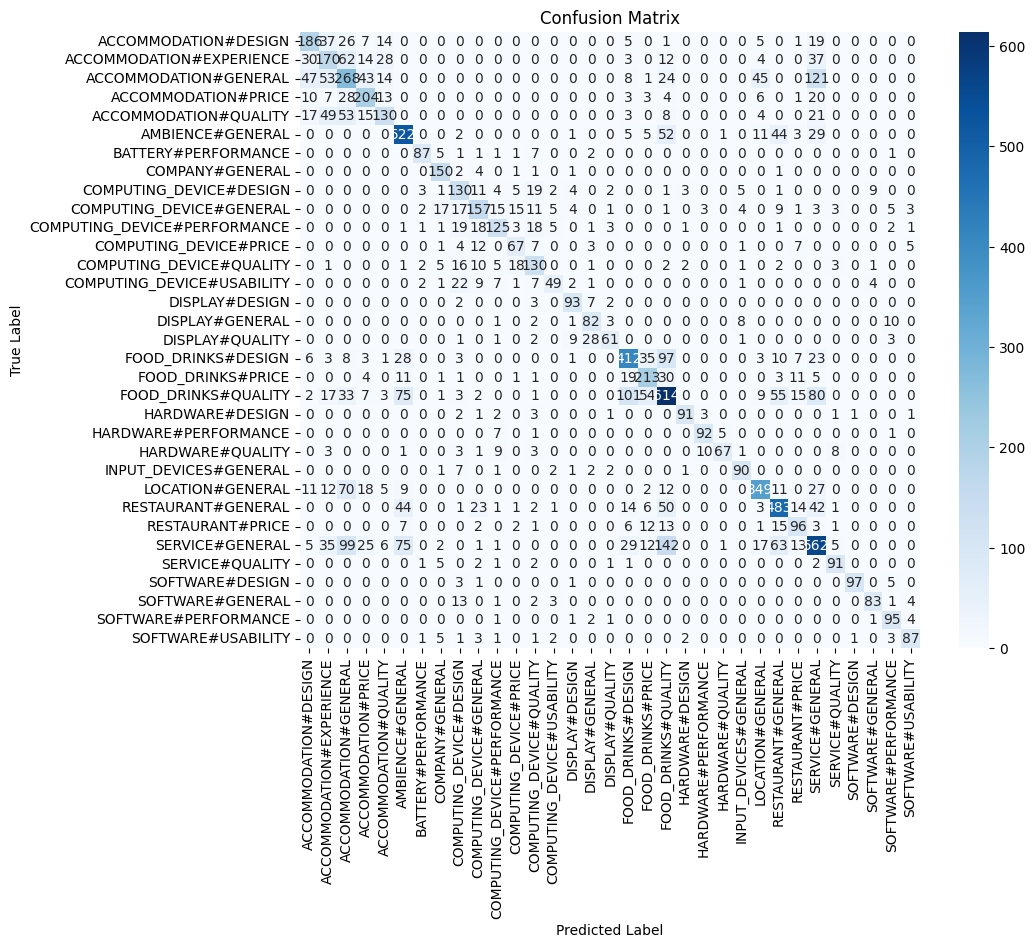


Detailed Classification Report:
                              precision    recall  f1-score   support

        ACCOMMODATION#DESIGN     0.5924    0.6179    0.6049       301
    ACCOMMODATION#EXPERIENCE     0.4393    0.4722    0.4552       360
       ACCOMMODATION#GENERAL     0.4142    0.4295    0.4217       624
         ACCOMMODATION#PRICE     0.6000    0.6823    0.6385       299
       ACCOMMODATION#QUALITY     0.6075    0.4333    0.5058       300
            AMBIENCE#GENERAL     0.6744    0.7733    0.7205       675
         BATTERY#PERFORMANCE     0.8788    0.8208    0.8488       106
             COMPANY#GENERAL     0.7653    0.9375    0.8427       160
     COMPUTING_DEVICE#DESIGN     0.5138    0.6500    0.5740       200
    COMPUTING_DEVICE#GENERAL     0.6085    0.5688    0.5880       276
COMPUTING_DEVICE#PERFORMANCE     0.6793    0.6250    0.6510       200
      COMPUTING_DEVICE#PRICE     0.5826    0.6262    0.6036       107
    COMPUTING_DEVICE#QUALITY     0.5804    0.6500    0.6

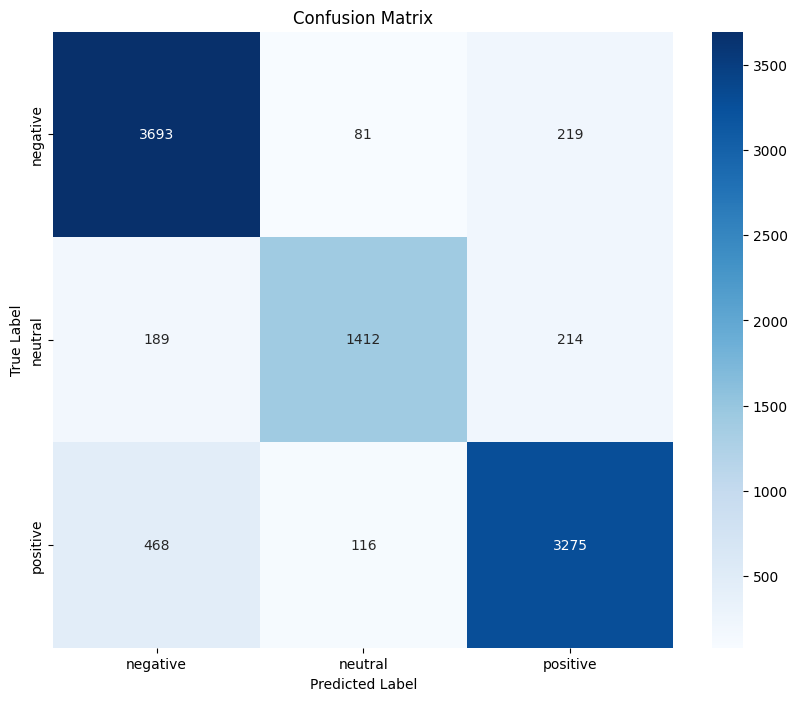


Detailed Classification Report:
              precision    recall  f1-score   support

    negative     0.8490    0.9249    0.8853      3993
     neutral     0.8776    0.7780    0.8248      1815
    positive     0.8832    0.8487    0.8656      3859

    accuracy                         0.8669      9667
   macro avg     0.8699    0.8505    0.8586      9667
weighted avg     0.8680    0.8669    0.8661      9667



In [80]:
def plot_confusion_matrix(y_true, y_pred, class_names=[ 'negative', 'neutral', 'positive']):
    """Plot confusion matrix với visualization đẹp hơn"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Print classification metrics
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
# Category
plot_confusion_matrix(category_labels, category_preds, class_names=le_cat.classes_)

# Polarity
plot_confusion_matrix(polarity_labels, polarity_preds, class_names=le_pol.classes_)


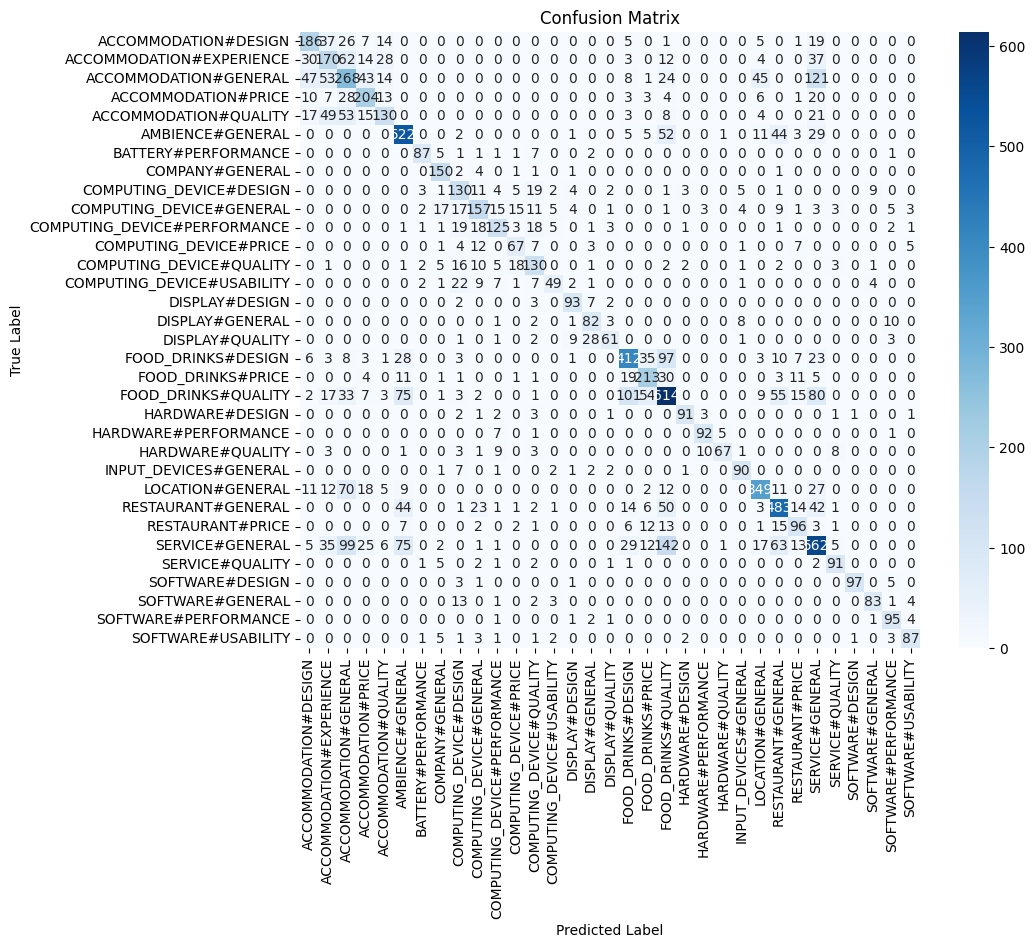


Detailed Classification Report:
                              precision    recall  f1-score   support

        ACCOMMODATION#DESIGN     0.5924    0.6179    0.6049       301
    ACCOMMODATION#EXPERIENCE     0.4393    0.4722    0.4552       360
       ACCOMMODATION#GENERAL     0.4142    0.4295    0.4217       624
         ACCOMMODATION#PRICE     0.6000    0.6823    0.6385       299
       ACCOMMODATION#QUALITY     0.6075    0.4333    0.5058       300
            AMBIENCE#GENERAL     0.6744    0.7733    0.7205       675
         BATTERY#PERFORMANCE     0.8788    0.8208    0.8488       106
             COMPANY#GENERAL     0.7653    0.9375    0.8427       160
     COMPUTING_DEVICE#DESIGN     0.5138    0.6500    0.5740       200
    COMPUTING_DEVICE#GENERAL     0.6085    0.5688    0.5880       276
COMPUTING_DEVICE#PERFORMANCE     0.6793    0.6250    0.6510       200
      COMPUTING_DEVICE#PRICE     0.5826    0.6262    0.6036       107
    COMPUTING_DEVICE#QUALITY     0.5804    0.6500    0.6

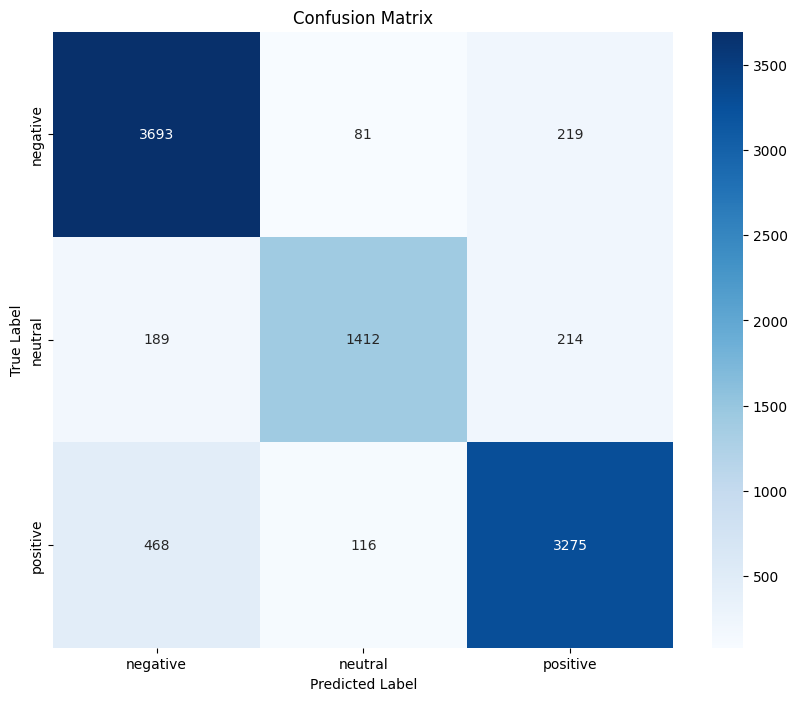


Detailed Classification Report:
              precision    recall  f1-score   support

    negative     0.8490    0.9249    0.8853      3993
     neutral     0.8776    0.7780    0.8248      1815
    positive     0.8832    0.8487    0.8656      3859

    accuracy                         0.8669      9667
   macro avg     0.8699    0.8505    0.8586      9667
weighted avg     0.8680    0.8669    0.8661      9667



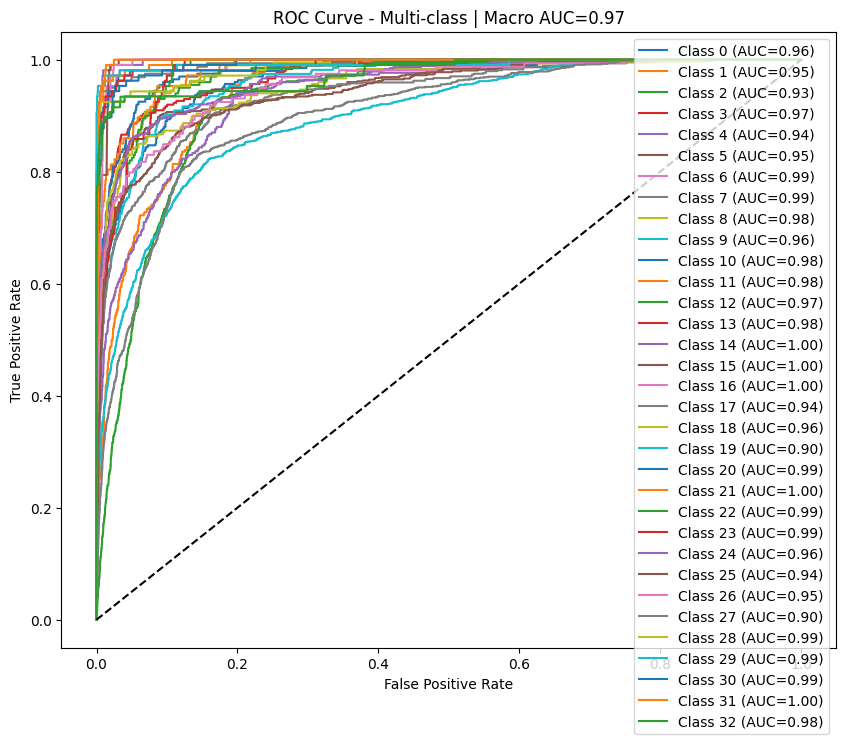

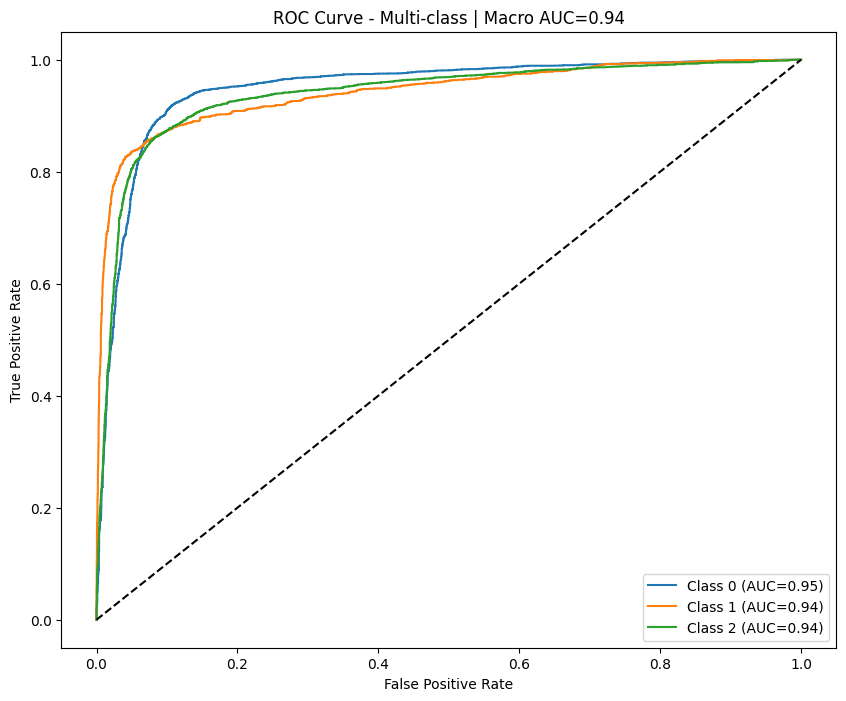

In [81]:
(cat_labels, cat_preds, cat_probs), (pol_labels, pol_preds, pol_probs) = evaluate_multitask(model, test_loader, DEVICE)

plot_confusion_matrix(cat_labels, cat_preds, class_names=le_cat.classes_)
plot_confusion_matrix(pol_labels, pol_preds, class_names=le_pol.classes_)

plot_roc(cat_labels, cat_probs)  # nếu bạn muốn ROC cho category
plot_roc(pol_labels, pol_probs, num_classes=len(le_pol.classes_))



In [ ]:
# ===============================
# 14. Load Best Model and Prediction Functions (Multi-Task)
# ===============================
def load_checkpoint(model, optimizer, filename):
    """Load model checkpoint"""
    try:
        checkpoint = torch.load(filename, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        epoch = checkpoint['epoch']
        loss = checkpoint['loss']
        le_cat.classes_ = np.array(checkpoint['le_cat_classes'])
        le_pol.classes_ = np.array(checkpoint['le_pol_classes'])
        print(f"Checkpoint loaded: epoch {epoch}, loss {loss:.4f}")
        return model, optimizer, epoch, loss
    except FileNotFoundError:
        print(f"Checkpoint file {filename} not found")
        return model, optimizer, 0, float('inf')

In [83]:
def predict_multitask(text, model, tokenizer, device, le_cat, le_pol):
    """Predict category + polarity for a single text"""
    model.eval()
    
    # Clean and tokenize text
    text = clean_text(text)
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs_cat, outputs_pol = model(input_ids, attention_mask)
        
        probs_cat = F.softmax(outputs_cat, dim=1).cpu().numpy()[0]
        pred_cat = np.argmax(probs_cat)
        label_cat = le_cat.inverse_transform([pred_cat])[0]
        
        probs_pol = F.softmax(outputs_pol, dim=1).cpu().numpy()[0]
        pred_pol = np.argmax(probs_pol)
        label_pol = le_pol.inverse_transform([pred_pol])[0]
    
    return {
        'category': label_cat,
        'category_confidence': float(probs_cat[pred_cat]),
        'category_probabilities': {le_cat.classes_[i]: float(probs_cat[i]) for i in range(len(probs_cat))},
        'polarity': label_pol,
        'polarity_confidence': float(probs_pol[pred_pol]),
        'polarity_probabilities': {le_pol.classes_[i]: float(probs_pol[i]) for i in range(len(probs_pol))}
    }





In [84]:
# Load best checkpoint
model, optimizer, _, _ = load_checkpoint(model, optimizer, '/kaggle/working/best_model_checkpoint.pth')

Checkpoint loaded: epoch 14, loss 1.0774


In [85]:
# Example prediction
sample_text = "This computer is absolutely AMAZING"
result = predict_multitask(sample_text, model, tokenizer, device, le_cat, le_pol)
print(f"Text: {sample_text}")
print(f"Prediction: {result}")

Text: This computer is absolutely AMAZING
Prediction: {'category': np.str_('COMPUTING_DEVICE#GENERAL'), 'category_confidence': 0.9945921301841736, 'category_probabilities': {np.str_('ACCOMMODATION#DESIGN'): 2.874020271241757e-15, np.str_('ACCOMMODATION#EXPERIENCE'): 9.545261716453757e-14, np.str_('ACCOMMODATION#GENERAL'): 1.6202885699811986e-09, np.str_('ACCOMMODATION#PRICE'): 5.332492107791185e-15, np.str_('ACCOMMODATION#QUALITY'): 2.628982101460231e-11, np.str_('AMBIENCE#GENERAL'): 5.9634412963305294e-09, np.str_('BATTERY#PERFORMANCE'): 3.2600511179481373e-09, np.str_('COMPANY#GENERAL'): 9.398063411936164e-05, np.str_('COMPUTING_DEVICE#DESIGN'): 1.943037932505831e-05, np.str_('COMPUTING_DEVICE#GENERAL'): 0.9945921301841736, np.str_('COMPUTING_DEVICE#PERFORMANCE'): 0.0025384663604199886, np.str_('COMPUTING_DEVICE#PRICE'): 4.0595456084702164e-05, np.str_('COMPUTING_DEVICE#QUALITY'): 0.0025945038069039583, np.str_('COMPUTING_DEVICE#USABILITY'): 3.656429908005521e-05, np.str_('DISPLAY#DE

In [86]:
result

{'category': np.str_('COMPUTING_DEVICE#GENERAL'),
 'category_confidence': 0.9945921301841736,
 'category_probabilities': {np.str_('ACCOMMODATION#DESIGN'): 2.874020271241757e-15,
  np.str_('ACCOMMODATION#EXPERIENCE'): 9.545261716453757e-14,
  np.str_('ACCOMMODATION#GENERAL'): 1.6202885699811986e-09,
  np.str_('ACCOMMODATION#PRICE'): 5.332492107791185e-15,
  np.str_('ACCOMMODATION#QUALITY'): 2.628982101460231e-11,
  np.str_('AMBIENCE#GENERAL'): 5.9634412963305294e-09,
  np.str_('BATTERY#PERFORMANCE'): 3.2600511179481373e-09,
  np.str_('COMPANY#GENERAL'): 9.398063411936164e-05,
  np.str_('COMPUTING_DEVICE#DESIGN'): 1.943037932505831e-05,
  np.str_('COMPUTING_DEVICE#GENERAL'): 0.9945921301841736,
  np.str_('COMPUTING_DEVICE#PERFORMANCE'): 0.0025384663604199886,
  np.str_('COMPUTING_DEVICE#PRICE'): 4.0595456084702164e-05,
  np.str_('COMPUTING_DEVICE#QUALITY'): 0.0025945038069039583,
  np.str_('COMPUTING_DEVICE#USABILITY'): 3.656429908005521e-05,
  np.str_('DISPLAY#DESIGN'): 2.59933029961301

In [87]:
from itertools import islice

sorted_probs = sorted(result["category_probabilities"].items(), 
                      key=lambda x: x[1], reverse=True)

top5 = list(islice(sorted_probs, 5))

print("Top 5 Aspect Categories:")
for cat, score in top5:
    print(f"{cat}: {score:.4f}")


Top 5 Aspect Categories:
COMPUTING_DEVICE#GENERAL: 0.9946
COMPUTING_DEVICE#QUALITY: 0.0026
COMPUTING_DEVICE#PERFORMANCE: 0.0025
COMPANY#GENERAL: 0.0001
RESTAURANT#GENERAL: 0.0001
